##Credit Risk Assessment

## 1. Importing Dependencies

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from scipy.stats import randint, uniform

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, cross_val_predict, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             confusion_matrix, classification_report, precision_recall_curve)
from xgboost import XGBClassifier


Loading dataset

In [2]:
df = pd.read_csv('D:\game\Credit_risk\credit_risk_dataset.csv')

<>:1: SyntaxWarning: invalid escape sequence '\g'
<>:1: SyntaxWarning: invalid escape sequence '\g'
C:\Users\Abhay Dixit\AppData\Local\Temp\ipykernel_5836\3058193386.py:1: SyntaxWarning: invalid escape sequence '\g'
  df = pd.read_csv('D:\game\Credit_risk\credit_risk_dataset.csv')


In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Exploratory Data Analysis (EDA)

In [4]:
df.shape

(32581, 12)

In [5]:
# Checking datatypes of features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
# Checking missing values
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
# Analysing 'loan_status' as it is our target column
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

-> Class imbalance ( as 0 -> 25475,

 1 -> 7108 )

<Axes: xlabel='loan_status', ylabel='count'>

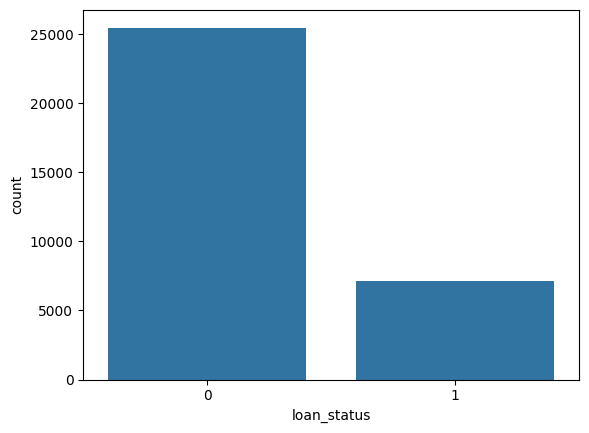

In [8]:
sns.countplot(x='loan_status', data=df)

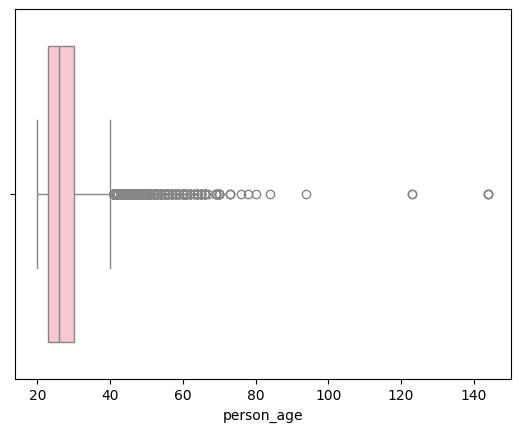

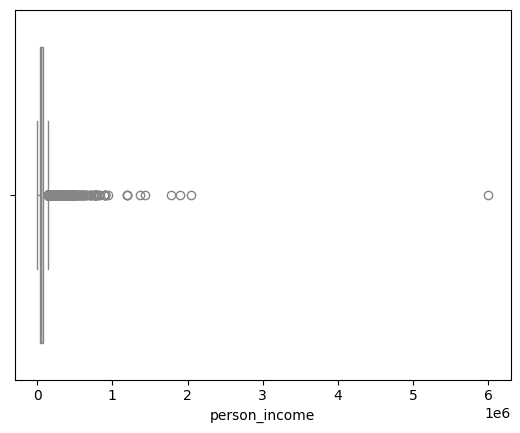

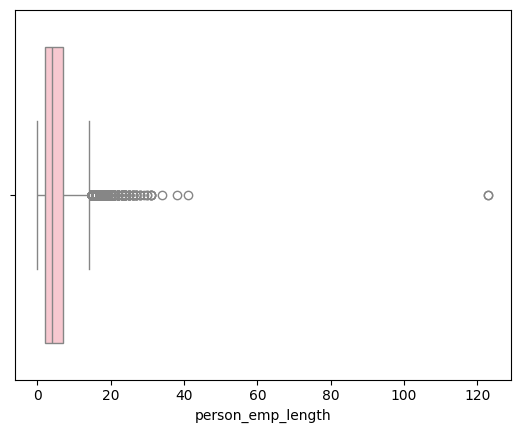

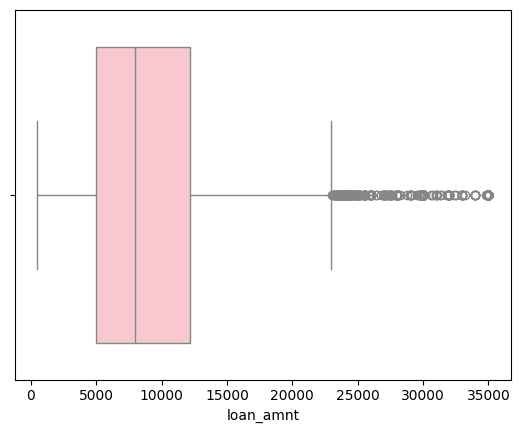

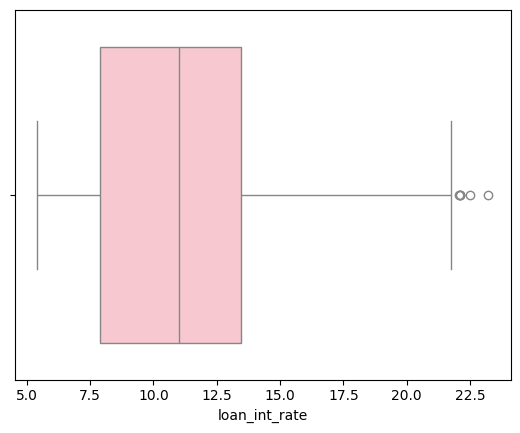

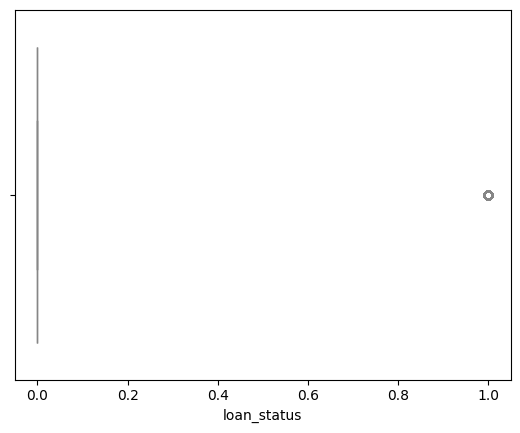

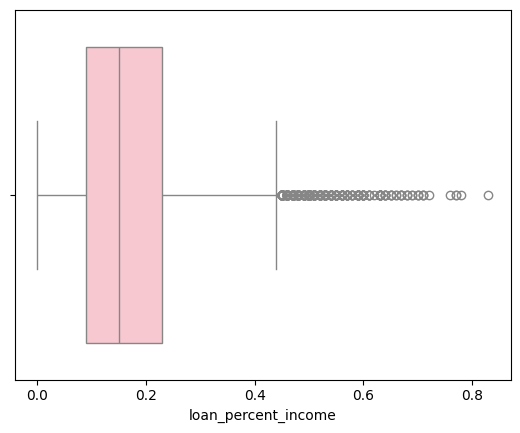

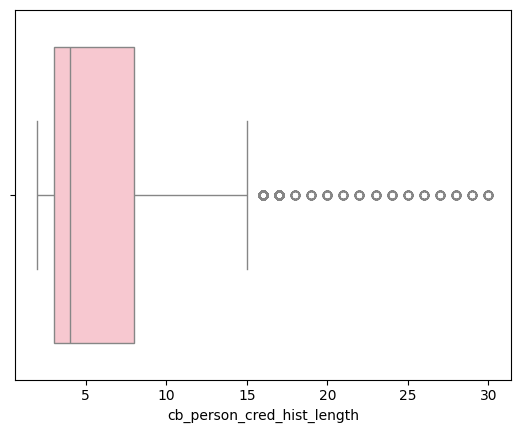

In [9]:
# extracting numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

for i in numerical_cols:
  sns.boxplot(x=i, data=df, color='pink')
  plt.show()


In [10]:
# looking for outliers in Age column
(df['person_age'] >100).sum()

np.int64(5)

In [11]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

In [12]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Correlation check

<Axes: >

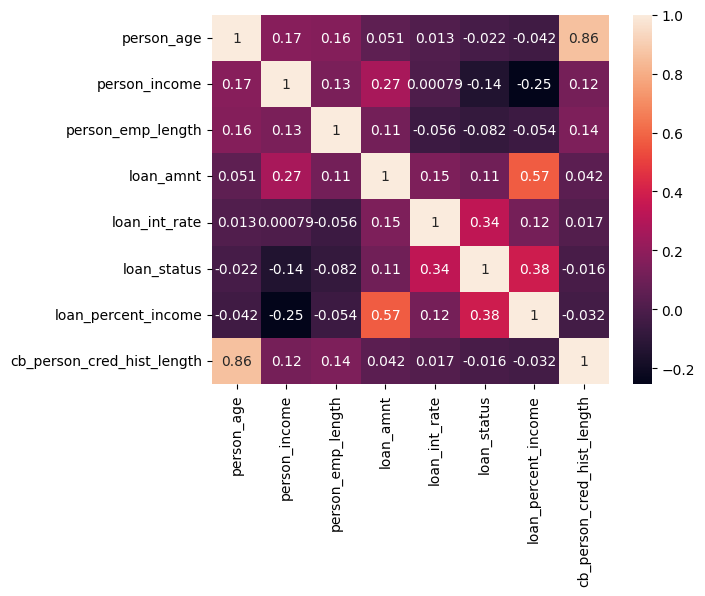

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## 3. Data Validation & Outlier Handling

In [14]:
# making a copy of dataset
df_copy = df.copy()

In [15]:
df_copy.duplicated().sum()


np.int64(165)

In [16]:
print(f"Original Rows: {df_copy.shape[0]}")

Original Rows: 32581


In [17]:
# Removing Duplicated rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates: {df_copy.shape[0]}")

Rows after removing duplicates: 32416


In [18]:
# Removing outliers ( Age below 18 & above 100)
df_copy = df_copy[df_copy['person_age'] >= 18]
df_copy = df_copy[df_copy['person_age'] <= 100]

# removing employment length ( grater than or extreme outliers (>60))
emp_ok = df_copy['person_emp_length'].isna() | (
    (df_copy['person_emp_length'] <= df_copy['person_age']) &
    (df_copy['person_emp_length'] <= 60)
)
df_copy = df_copy[emp_ok]

df_copy = df_copy[df_copy['loan_amnt'] > 0]

#checking if loan interest rate look realistic
print(f"Rows after cleaning: {df_copy.shape[0]}")
print(f"Loan interest rate range: min {df_copy['loan_int_rate'].min()}, "
      f"max {df_copy['loan_int_rate'].max()}")


Rows after cleaning: 32409
Loan interest rate range: min 5.42, max 23.22


In [19]:
df_copy.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32409.000000,3.240900e+04,31522.000000,32409.000000,29315.000000,32409.000000,32409.000000,32409.000000
mean,27.730754,6.589428e+04,4.782850,9592.486655,11.017099,0.218705,0.170248,5.811194
std,6.210445,5.251787e+04,4.037343,6320.885127,3.241718,0.413374,0.106785,4.057899
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## 4. Features, Train-Test split

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X = df_copy.drop('loan_status', axis=1)
Y = df_copy['loan_status']

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [23]:
print(numerical_cols)

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')


In [24]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


In [25]:
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file']

## 5. Handling Class imbalance

In [26]:
# 0 -> no loan(most)
# 1 -> yes loan

neg, pos = np.bincount(Y_train)
scale_weights = neg/pos

In [27]:
scale_weights

np.float64(3.572663139329806)

## 6. Data preprocessing - Pipelines & Columns Transformer

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [29]:
# Logistic Regression : impute + SCALE Numeric, impute + One-Hot-Encoding
preprocessor_lr = ColumnTransformer(
    transformers=[

        # Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),

        # Pipeline - for Categorical cols
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)

    ])


In [30]:
# XGBoost : impute numeric only (no scaling), impute + One hot Encoding

preprocessor_xgb = ColumnTransformer(
    transformers=[

        # Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numerical_cols),

        # Pipeline - for Categorical cols
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)

    ])


## 7. Evaluation Helper Function

In [31]:
# Evaluating Logistic Model and XGBoost Model on the basis of their metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, precision_recall_curve, average_precision_score

def evaluate_model(model_name, model, X_test, Y_test, threshold=None):
    
    used_threshold = 0.5 if threshold is None else threshold

    Y_pred_prob = model.predict_proba(X_test)[:, 1]
    Y_pred = (Y_pred_prob >= used_threshold).astype(int)

    metrics = {
        'Model': model_name,
        'Threshold': used_threshold,
        'Accuracy': accuracy_score(Y_test, Y_pred),
        'Precision': precision_score(Y_test, Y_pred, zero_division=0),
        'Recall': recall_score(Y_test, Y_pred, zero_division=0),
        'F1': f1_score(Y_test, Y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(Y_test, Y_pred_prob),
        'PR-AUC': average_precision_score(Y_test, Y_pred_prob),
    }

    print(f"{model_name} Metrics (threshold = {used_threshold:.3f}):")
    for k in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']:
        print(f"{k}: {metrics[k]:.3f}")
    print(f"\n{model_name} Classification Report:")
    print(classification_report(Y_test, Y_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(Y_test, Y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted values")
    plt.ylabel("Actual values")
    plt.show()

    # Precision-Recall curve (correct title this time)
    precisions, recalls, _ = precision_recall_curve(Y_test, Y_pred_prob)
    plt.plot(recalls, precisions)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} Precision-Recall Curve")
    plt.show()

    return metrics

## 8. Stratified Cross-Validation

In [32]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring ={'roc_auc': 'roc_auc', 'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}

In [33]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [34]:
# XGBoost Model
from xgboost import XGBClassifier

xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('classifier', XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_weights, eval_metric= 'logloss', random_state=42
    ))
])

xgb_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [35]:
for cv_name, pipe in [('Logistic Regression', lr_cv_pipeline),
                      ('XGBoost', xgb_cv_pipeline)]:

                     cv_results = cross_validate(pipe, X_train, Y_train, cv=cv, scoring=scoring, n_jobs=-1)

                     print(cv_name)
                     print(f"ROC-AUC:  {cv_results['test_roc_auc'].mean()}")
                     print(f"Accuracy: {cv_results['test_accuracy'].mean()}")
                     print(f"Precision: {cv_results['test_precision'].mean()}")
                     print(f"Recall: {cv_results['test_recall'].mean()}")
                     print(f"F1: {cv_results['test_f1'].mean()}")
                     print()

Logistic Regression
ROC-AUC:  0.8702172732054532
Accuracy: 0.8123188199369193
Precision: 0.5504124367547936
Recall: 0.7754850088183421
F1: 0.6438157956858388

XGBoost
ROC-AUC:  0.9470765243699957
Accuracy: 0.9147604503036696
Precision: 0.8120992214667074
Recall: 0.7941798941798941
F1: 0.8029964314971819



## 9. Baseline Model - Logistic Regression

In [36]:

baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced'))
])
baseline_model.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

Logistic Regression Metrics (threshold = 0.500):
Accuracy: 0.806
Precision: 0.539
Recall: 0.782
F1: 0.638
ROC-AUC: 0.872
PR-AUC: 0.708

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      5064
           1       0.54      0.78      0.64      1418

    accuracy                           0.81      6482
   macro avg       0.73      0.80      0.75      6482
weighted avg       0.84      0.81      0.82      6482



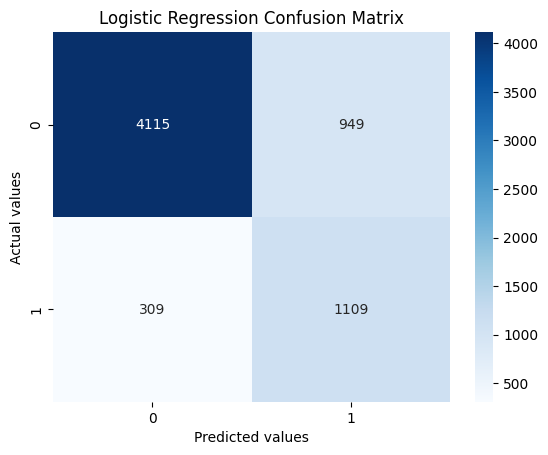

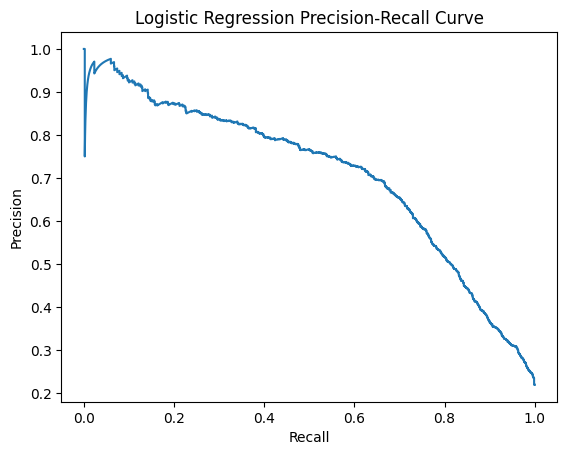

{'Model': 'Logistic Regression',
 'Threshold': 0.5,
 'Accuracy': 0.8059240975007713,
 'Precision': 0.5388726919339164,
 'Recall': 0.7820874471086037,
 'F1': 0.6380897583429229,
 'ROC-AUC': np.float64(0.8715641481560705),
 'PR-AUC': np.float64(0.7081974594210094)}

In [37]:
# Evaluate Logistic Model
evaluate_model('Logistic Regression', baseline_model, X_test, Y_test)

## 10. XGBoost hyperparameter Tuning

In [38]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('classifier', XGBClassifier(learning_rate=0.1,
        scale_pos_weight=scale_weights,eval_metric='logloss',random_state=42))
])
xg_model.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [39]:
from scipy.stats import randint, uniform


In [40]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'classifier__n_estimators': randint(150,600),
    'classifier__max_depth': randint(3, 9),
    'classifier__learning_rate': uniform(0.01, 0.5),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__min_child_weight': randint(1, 10),
    'classifier__gamma': uniform(0, 5)
}

In [41]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000158E6CAFB10>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000158E5B9E900>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000158E6CAF9D0>},
                   random_state=42, scoring='average_precision', verbose=1)

In [42]:
print(f"Best CV PR-AUC (average precision) after tuning: {random_search.best_score_:.3f}")

Best CV PR-AUC (average precision) after tuning: 0.905


In [43]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.8497416192535173),
 'classifier__gamma': np.float64(1.47816842918857),
 'classifier__learning_rate': np.float64(0.0627471299151353),
 'classifier__max_depth': 6,
 'classifier__min_child_weight': 4,
 'classifier__n_estimators': 435,
 'classifier__subsample': np.float64(0.9533121035675474)}

## 11. Compare Both Models side by side

Logistic Regression (baseline) Metrics (threshold = 0.500):
Accuracy: 0.806
Precision: 0.539
Recall: 0.782
F1: 0.638
ROC-AUC: 0.872
PR-AUC: 0.708

Logistic Regression (baseline) Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      5064
           1       0.54      0.78      0.64      1418

    accuracy                           0.81      6482
   macro avg       0.73      0.80      0.75      6482
weighted avg       0.84      0.81      0.82      6482



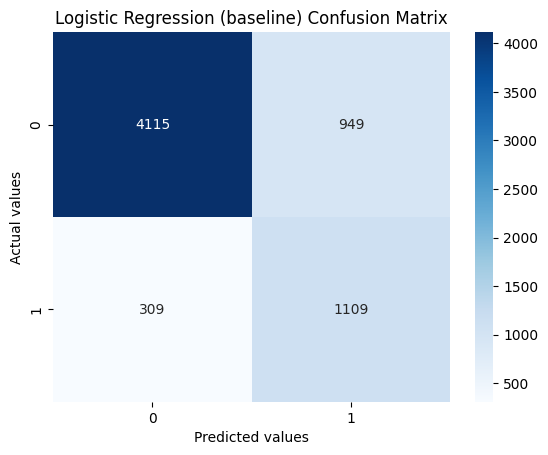

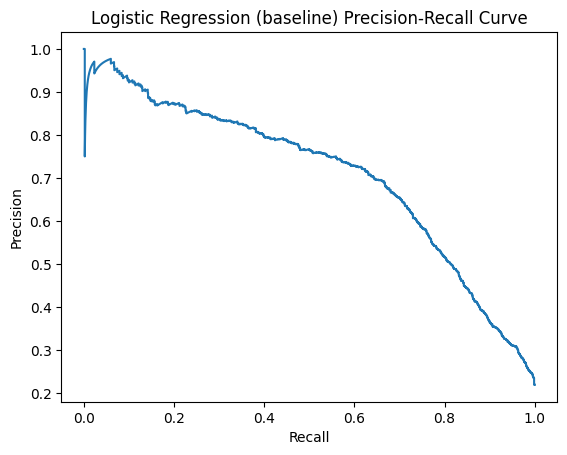

XGBoost (untuned) Metrics (threshold = 0.500):
Accuracy: 0.917
Precision: 0.808
Recall: 0.815
F1: 0.811
ROC-AUC: 0.950
PR-AUC: 0.908

XGBoost (untuned) Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      5064
           1       0.81      0.81      0.81      1418

    accuracy                           0.92      6482
   macro avg       0.88      0.88      0.88      6482
weighted avg       0.92      0.92      0.92      6482



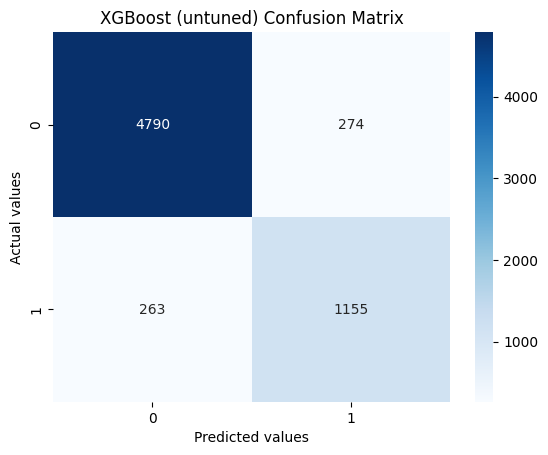

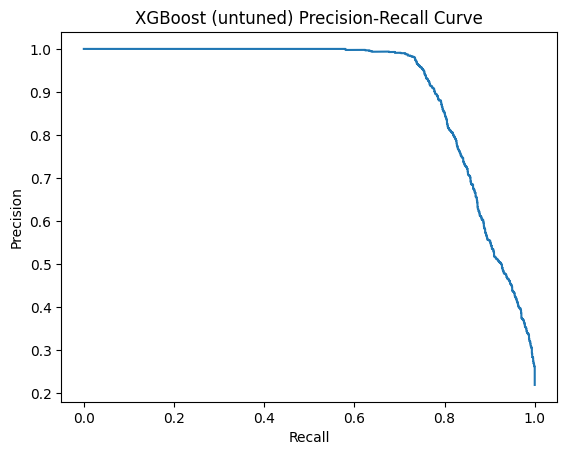

XGBoost (tuned) Metrics (threshold = 0.500):
Accuracy: 0.923
Precision: 0.830
Recall: 0.817
F1: 0.824
ROC-AUC: 0.954
PR-AUC: 0.914

XGBoost (tuned) Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      5064
           1       0.83      0.82      0.82      1418

    accuracy                           0.92      6482
   macro avg       0.89      0.89      0.89      6482
weighted avg       0.92      0.92      0.92      6482



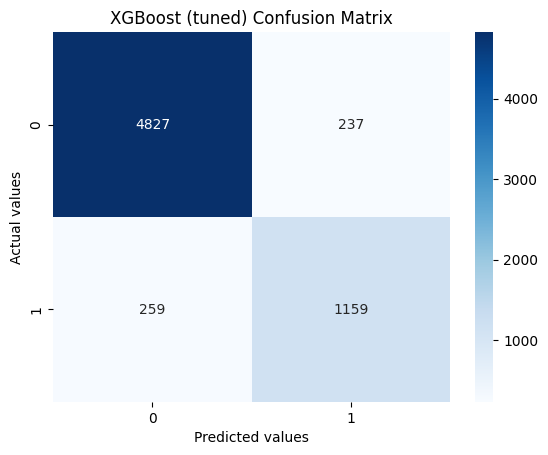

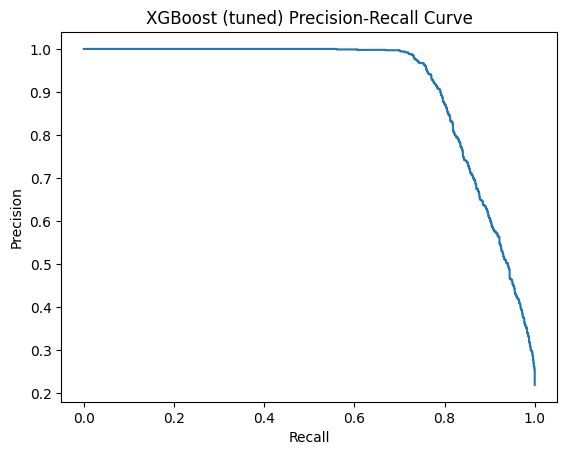

In [44]:
xgb_tuned = random_search.best_estimator_

print("=" * 50)
lr_metrics = evaluate_model('Logistic Regression (baseline)', baseline_model, X_test, Y_test)
print("=" * 50)
xgb_default_metrics = evaluate_model('XGBoost (untuned)', xg_model, X_test, Y_test)
print("=" * 50)
xgb_tuned_metrics = evaluate_model('XGBoost (tuned)', xgb_tuned, X_test, Y_test)

In [45]:
comparison = pd.DataFrame([lr_metrics, xgb_default_metrics, xgb_tuned_metrics]).set_index('Model')
comparison.round(3)

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,,
Logistic Regression (baseline),0.5,0.806,0.539,0.782,0.638,0.872,0.708
XGBoost (untuned),0.5,0.917,0.808,0.815,0.811,0.950,0.908
XGBoost (tuned),0.5,0.923,0.830,0.817,0.824,0.954,0.914


## 12. Probability Calibration
`scale_pos_weight` inflates the predicted probabilities, so we calibrate the **tuned** model.

In [46]:
# Calibrating XGBoost Model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv=5
)
calibrated_model.fit(X_train, Y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.0627471299151353),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=6,
                                                                max_leaves=None,
                                                                min_child_weight=4,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=435,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [47]:
# Getting Probabilities
from sklearn.metrics import brier_score_loss
uncalibrated = best_model.predict_proba(X_test)[:, 1]
calibrated = calibrated_model.predict_proba(X_test)[:, 1]

print(f"Brier score (uncalibrated): {brier_score_loss(Y_test, uncalibrated):.4f}")
print(f"Brier score (calibrated):   {brier_score_loss(Y_test, calibrated):.4f}")



Brier score (uncalibrated): 0.0629
Brier score (calibrated):   0.0510


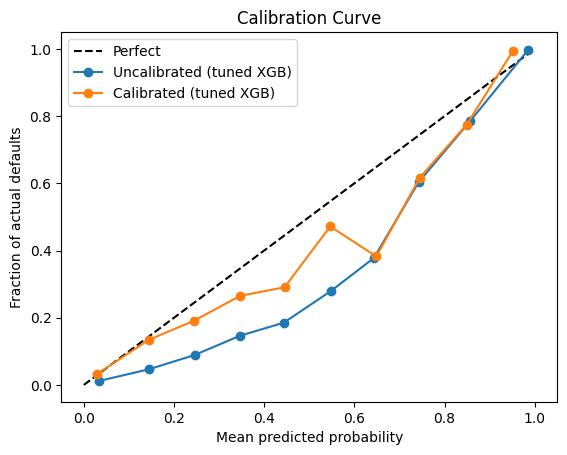

In [48]:
#creating calibration curve
frac_pos_uncal, mean_pred_uncal = calibration_curve(Y_test, uncalibrated, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(Y_test, calibrated, n_bins=10)

plt.plot([0, 1], [0, 1], 'k--', label='Perfect')
plt.plot(mean_pred_uncal, frac_pos_uncal, 'o-', label='Uncalibrated (tuned XGB)')
plt.plot(mean_pred_cal, frac_pos_cal, 'o-', label='Calibrated (tuned XGB)')
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of actual defaults")
plt.title("Calibration Curve")
plt.legend()
plt.show()

## 13. Optimizing the Classification Threshold
The threshold is chosen on **out-of-fold predictions from the training set**, never on the test set.

In [49]:
# Out-of-fold calibrated probabilities on TRAIN data only
oof_proba = cross_val_predict(
    CalibratedClassifierCV(best_model, method='sigmoid', cv=cv),
    X_train, Y_train,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(Y_train, oof_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

best_idx = np.argmax(f1_scores[:-1])
best_threshold = float(thresholds[best_idx])
print(f"Best threshold (from train out-of-fold): {best_threshold:.4f}")
print(f"OOF F1 at that threshold: {f1_scores[best_idx]:.3f}")

Best threshold (from train out-of-fold): 0.5633
OOF F1 at that threshold: 0.830


XGBoost (tuned + calibrated) Metrics (threshold = 0.563):
Accuracy: 0.938
Precision: 0.942
Recall: 0.762
F1: 0.843
ROC-AUC: 0.954
PR-AUC: 0.914

XGBoost (tuned + calibrated) Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      5064
           1       0.94      0.76      0.84      1418

    accuracy                           0.94      6482
   macro avg       0.94      0.87      0.90      6482
weighted avg       0.94      0.94      0.94      6482



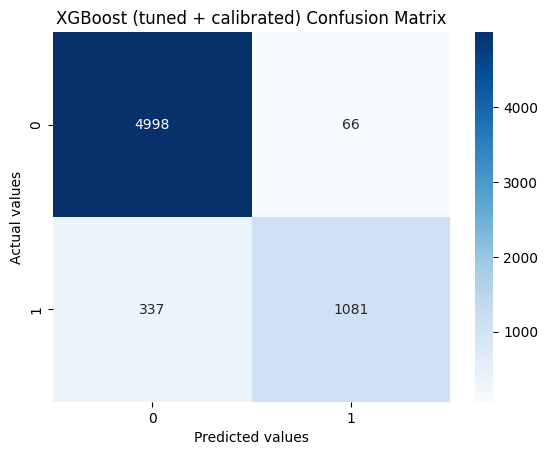

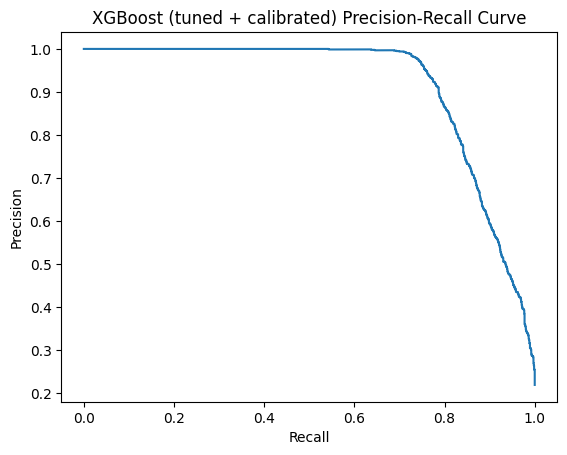

In [50]:
final_metrics = evaluate_model('XGBoost (tuned + calibrated)', calibrated_model,
                               X_test, Y_test, threshold=best_threshold)

## 14. Model Explainability (SHAP)

In [51]:
# Getting Trained XGBoost classifier model out of pipeline
xgb_classifier = xg_model.named_steps['classifier']


In [52]:
# Transforming X_test using same preprocessing used for training
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)


In [53]:
# Getting feature names after one-hot encoding
feature_names= xg_model.named_steps['preprocessor'].get_feature_names_out()

In [54]:
# Converting to dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)


In [55]:
# Creating SHAP explainer built for tree-based model
explainer = shap.TreeExplainer(xgb_classifier)

In [56]:
# Calculating SHAP values for every row in test set
shap_values = explainer.shap_values(X_test_df)

Global Explaination

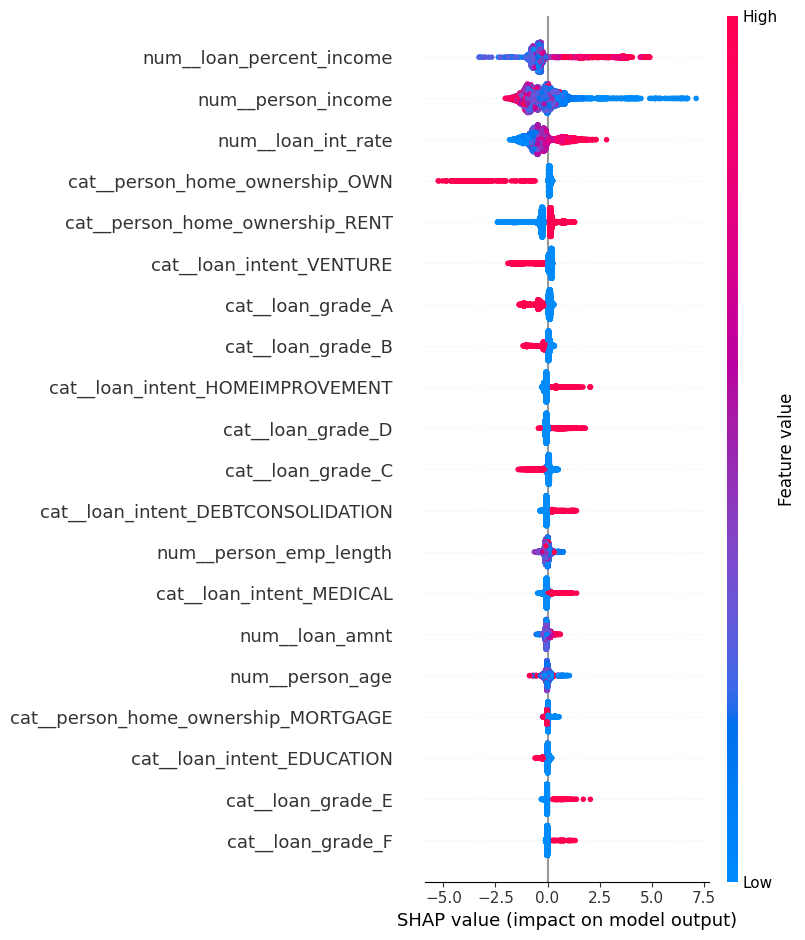

In [57]:
shap.summary_plot(shap_values, X_test_df)

Local Explaination

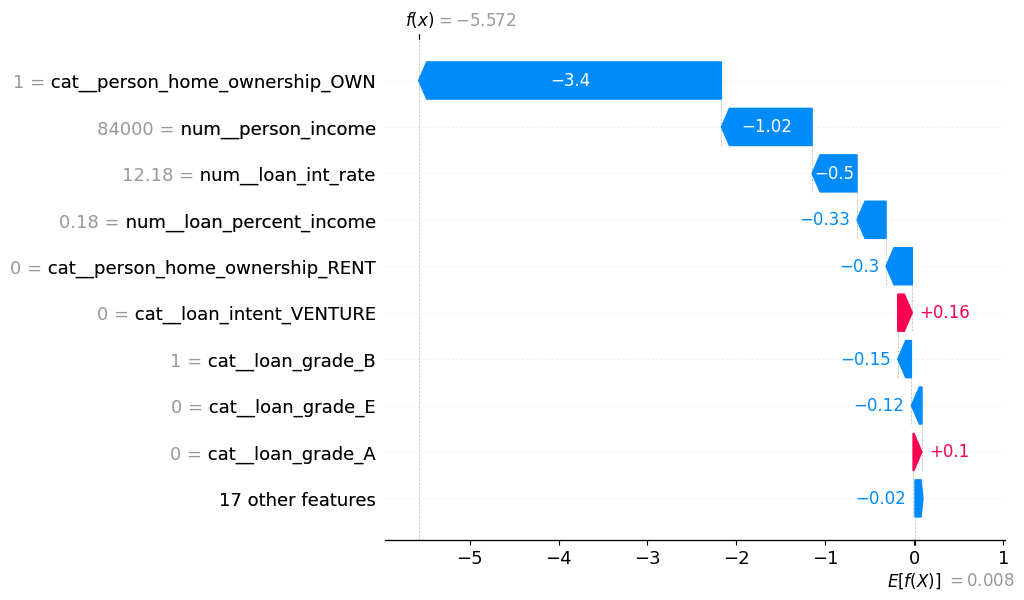

In [58]:
# Picking one row to explain, e.g 5th applicant in test set
row_index = 5

# Drafting a Waterfall plot showing how much each feature pushed prediction up or down
shap.plots.waterfall(

    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index].values,
        feature_names = feature_names

    )
)

## 15. Analyzing False Positives & False Negatives

False Positive -> *Safe* (actual=0) people actually marked ***Risky***(predicted=1)


False Negative -> *risky* (actual=1)people actually marked ***Safe***(predicted=0)

In [59]:
# Predictions from best performing XGBoost model on test set
Y_pred = random_search.predict(X_test)

In [60]:
# Creating a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = Y_test
result_df['predicted'] = Y_pred

In [61]:
# Identify False Positive:
# Model -> 1, actual -> 0
false_positive = result_df[(result_df['actual']==0) & (result_df['predicted']==1)]

# Identify False Negative:
# Model -> 0, actual -> 1
false_negative = result_df[(result_df['actual']==1) & (result_df['predicted']==0)]


In [62]:
print(f'False Positive: {len(false_positive)}')
print(f'False Negative: {len(false_negative)}')

False Positive: 237
False Negative: 259


In [63]:
profile = pd.DataFrame({
    'False Positive': false_positive[numerical_cols].mean(),
    'False Negative': false_negative[numerical_cols].mean(),
    'All test data': X_test[numerical_cols].mean()
}).round(2)
profile

,False Positive,False Negative,All test data
person_age,27.35,27.50,27.89
person_income,49839.44,64028.33,66264.05
person_emp_length,5.19,5.04,4.77
loan_amnt,9188.82,9086.78,9634.88
loan_int_rate,13.50,11.17,10.95
loan_percent_income,0.19,0.15,0.17
cb_person_cred_hist_length,5.58,5.67,5.89


## 16. Saving The Model

In [64]:
import joblib

joblib.dump(calibrated_model, 'credit_risk_model.pkl')
joblib.dump(best_threshold, 'best_threshold.pkl')

print("Saved credit_risk_model.pkl and best_threshold.pkl")

Saved credit_risk_model.pkl and best_threshold.pkl


In [65]:
import os

model = joblib.load('credit_risk_model.pkl')
threshold = joblib.load('best_threshold.pkl')

print("Threshold:", threshold)
print("Sample predictions:", (model.predict_proba(X_test)[:5, 1] >= threshold).astype(int))

Threshold: 0.5632788513628928
Sample predictions: [0 0 0 0 1]
